In [1]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 
from datetime import date, timedelta


# TODO
### Test low frequency and high frequency VOL_INTERVAL

# PB
#### Transition to Darts TimeSeries makes a lot lot NaN values (5000 for a 17000 df on hour interval)

### Variables

In [2]:
CURRENCIE_TICKER = "EURUSD=X" #, "CAD=X"
START_DATE, END_DATE = "2014-01-01", "2024-01-01"
#for 1d "2014-01-01", "2024-01-01"
#for 5m (date.today() - timedelta(days=59)).isoformat(), date.today().isoformat() 
# for 1h (date.today() - timedelta(days=720)).isoformat(), date.today().isoformat() 
# for less than 1h interval, only 60 LAST days data are saved. For 1m, only 8 LAST days

TRAIN_SIZE = 0.75
VAL_SIZE = 0.15

VOL_INTERVAL = "1d" #In "1m”, “2m”, “5m”, “15m”, “30m”, “60m”, “90m”, “1h”, “1d”, “5d”, “1wk”, “1mo”, “3mo”
#REALISED_VOL_INTERVAL = "1h"

ROLLING_WINDOW = 5  #for the variance, 24 if hourly for exemple



# Data

In [3]:

data = yf.download(CURRENCIE_TICKER, start=START_DATE, end=END_DATE, interval=VOL_INTERVAL, progress=False)
data_prices = data["Close"].copy()
data_prices.dropna(inplace=True)

data_prices.set_index(data_prices.index, inplace=True)
data_prices.columns = [CURRENCIE_TICKER]

data_log_returns = np.log(data_prices / data_prices.shift(1)).dropna()*100 + 1.e-08 
data_log_returns_sq = data_log_returns**2

# check data
print(data_log_returns.info())
data_log_returns_sq.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2604 entries, 2014-01-02 to 2023-12-29
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2604 non-null   float64
dtypes: float64(1)
memory usage: 40.7 KB
None


,EURUSD=X
Date,
2014-01-02,0.025027
2014-01-03,0.532492
2014-01-06,0.268315
2014-01-07,0.069759
2014-01-08,0.013098


# PLOT


In [4]:
df = data_log_returns.copy()[CURRENCIE_TICKER].rolling(ROLLING_WINDOW).var()
df.drop(df.index[:ROLLING_WINDOW], inplace=True)
len(df)

2599

In [5]:
# pre traitement pour faire apparaitre tous les indices pour éviter les NaN dans TimeSeries
df_ts =  TimeSeries.from_dataframe(df.to_frame().asfreq(VOL_INTERVAL), freq="B")
df = pd.DataFrame(df_ts.values(), index=df_ts.time_index).interpolate(method="time")
df_ts = TimeSeries.from_dataframe(df.asfreq(VOL_INTERVAL))
len(df)

3642

In [7]:
df[df.isna().any(axis=1)] 

,0
Date,


In [8]:
train_end = int(TRAIN_SIZE * len(df))
val_end   = int((TRAIN_SIZE + VAL_SIZE) * len(df))


df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

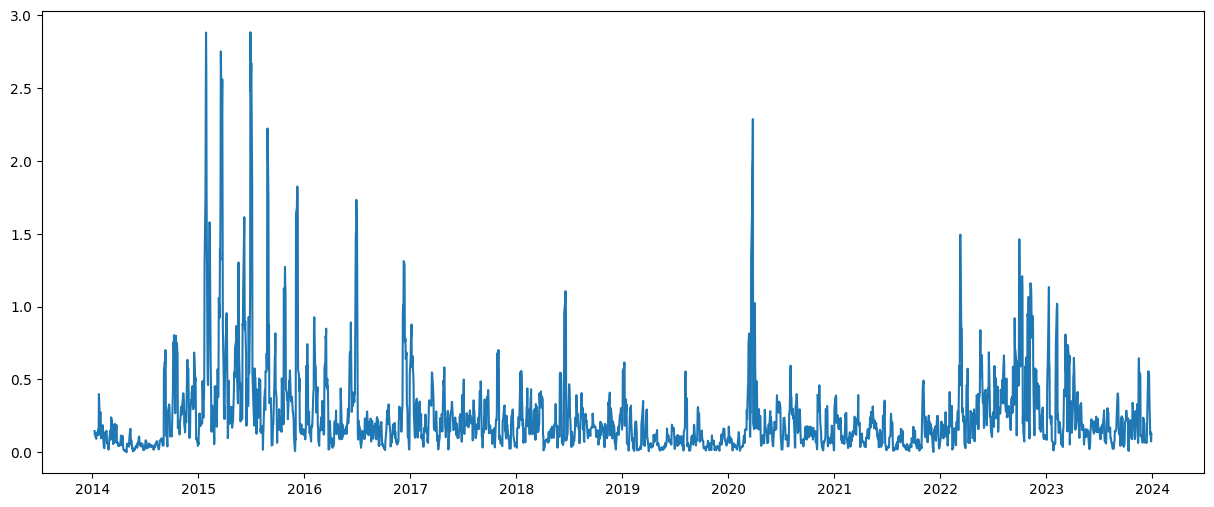

In [6]:
plt.figure(figsize=(15,6))
plt.plot(df.index, df.values)

In [30]:
print(df_train.index.min(), df_train.index.max())
print(df_val.index.min(), df_val.index.max())
print(df_test.index.min(), df_test.index.max())

2014-01-09 00:00:00 2021-07-01 00:00:00
2021-07-02 00:00:00 2022-12-29 00:00:00
2022-12-30 00:00:00 2023-12-29 00:00:00


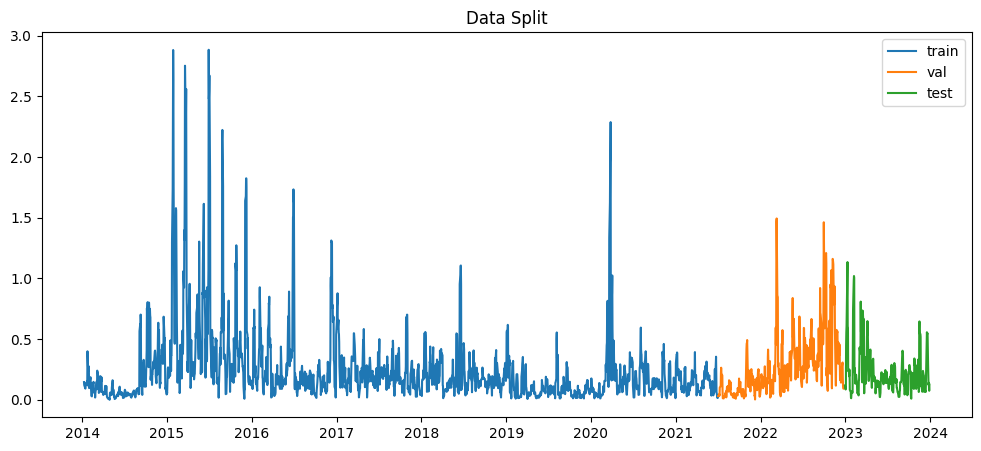

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(df_train.index, df_train, label="train")
plt.plot(df_val.index, df_val, label="val")
plt.plot(df_test.index, df_test, label="test")

plt.title("Data Split")
plt.legend()
plt.show()

In [32]:
df_train[pd.DataFrame(df_train).isna().any(axis=1)] 

,0
Date,


# Scaler

In [35]:
# Résolu : (des NaN apparaissent car il manque surement des heures dans la continuité)
df_ts =  TimeSeries.from_dataframe(df.asfreq(VOL_INTERVAL))
train_ts = TimeSeries.from_dataframe(df_train.asfreq(VOL_INTERVAL))
val_ts = TimeSeries.from_dataframe(df_val.asfreq(VOL_INTERVAL))
test_ts =  TimeSeries.from_dataframe(df_test.asfreq(VOL_INTERVAL))

In [36]:
df_ts.to_dataframe().isna().sum()

0    0
dtype: int64

In [37]:
scaler = Scaler(MinMaxScaler(feature_range=(-1,1))) 

train_scaled = scaler.fit_transform(train_ts)
val_scaled = scaler.transform(val_ts)
test_scaled = scaler.transform(test_ts)
df_scaled = scaler.transform(df_ts)

# NBEATS

In [38]:
seed = 42
nbeats_name = "nbeats_1h"

# parameters
params = {
    'input_lags': 20,
    'output_steps': 1,
    'stacks': 5,
    'blocks': 1,
    'layers': 4,
    'l_widths': 256,
    'epochs': 100,
    'b_size': 32
}

In [39]:

start = time.time()
model_nbeats = NBEATSModel(
    input_chunk_length=params['input_lags'],       # use last 20 observations
    output_chunk_length=params['output_steps'],       # forecast 1 step ahead
    generic_architecture=True,
    num_stacks=params['stacks'],
    num_blocks=params['blocks'],
    num_layers=params['layers'],
    layer_widths=params['l_widths'],
    n_epochs=params['epochs'], 
    batch_size=params['b_size'],
    random_state=seed,
    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True,
)

# fit model
history = model_nbeats.fit(
    train_scaled, 
    val_series=val_scaled,
    verbose=True)


end = time.time()

time_spent = end - start

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 1.0 M  | train
-------------------------------------------------------------
1.0 M     Trainable params
1.4 K     Non-trainable params
1.0 M     Total params
4.109     Total estimated model params size (MB)
71        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [40]:
mins, secs = time_spent // 60, time_spent % 60 
print(f'Time elapsed: {int(mins)}m {secs}s')

Time elapsed: 5m 2.890892744064331s


In [41]:
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=nbeats_name, best=True)

pred_scaled = model_nbeats.historical_forecasts(
    series=df_scaled,
    start=df_test.index.min().replace(tzinfo=None),
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=False,
    verbose=True
)

# inverse scaling
pred = scaler.inverse_transform(pred_scaled)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

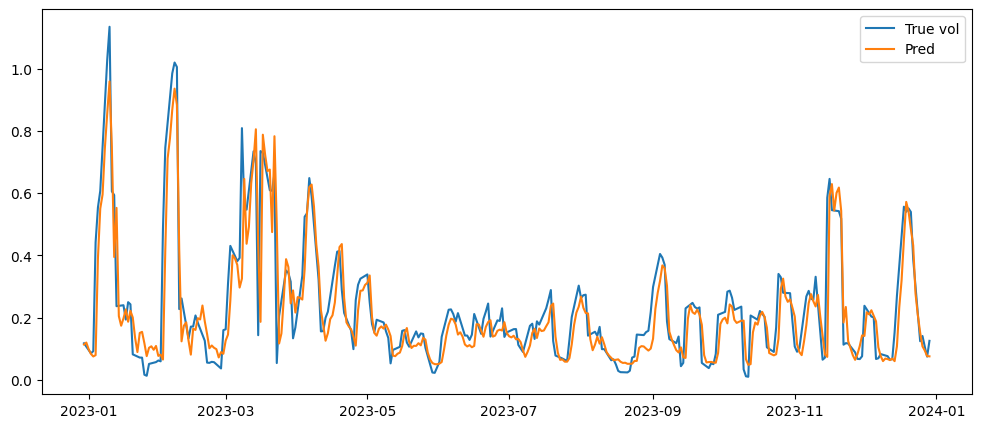

In [46]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(test_ts.time_index, test_ts.values(), label="True vol")
plt.plot(test_ts.time_index, pred.values(), label="Pred")
plt.legend()
plt.show()

#### mediocre MAPE

In [43]:
mean_absolute_percentage_error(pred.values(), test_ts.values())

0.37478819385163403

In [44]:
mean_squared_error(pred.values(), test_ts.values())

0.008552881130437834

# GARCH

In [50]:
df_garch = data_log_returns.copy()
# pre traitement pour faire apparaitre tous les indices 
tmp =  TimeSeries.from_dataframe(df_garch.asfreq(VOL_INTERVAL))
df_garch = pd.DataFrame(tmp.values(), index=tmp.time_index).interpolate(method="time")
df_garch[df_garch.isna().any(axis=1)] 

,0
Date,


In [54]:
train_end   = int((TRAIN_SIZE + VAL_SIZE) * len(df))


df_garch_train = df_garch.iloc[:train_end]
df_garch_test   = df_garch.iloc[train_end:]

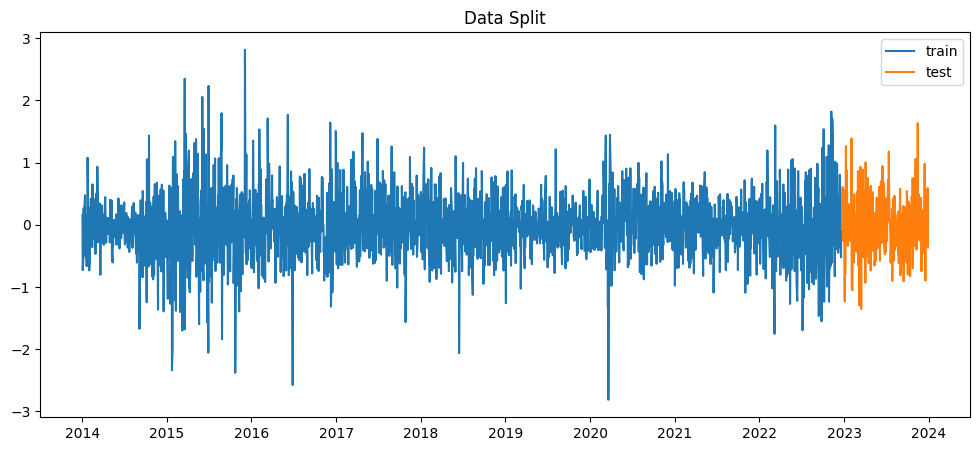

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(df_garch_train.index, df_garch_train, label="train")
plt.plot(df_garch_test.index, df_garch_test, label="test")

plt.title("Data Split")
plt.legend()
plt.show()

In [56]:
garch_model = arch_model(
    df_garch_train,
    vol='GARCH',
    p=1,
    q=1
)
res = garch_model.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      0   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1951.76
Distribution:                  Normal   AIC:                           3911.52
Method:            Maximum Likelihood   BIC:                           3935.90
                                        No. Observations:                 3277
Date:                Thu, Apr 02 2026   Df Residuals:                     3276
Time:                        09:53:50   Df Model:                            1
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0144  7.108e-03     -2.023  4.312e-

In [150]:
history = list(df_garch_train.iloc[:,0].values)

sigma2_preds = []
sigma2_true = []

for t in range(len(df_garch_test)):
    
    # Refit avec toutes les vraies données jusqu'à t
    garch_model = arch_model(history[-20:], vol='GARCH', p=2, q=2, mean='Constant')
    res = garch_model.fit(disp="off")
    
    forecast = res.forecast(horizon=1)
    
    sigma2_t = forecast.variance.values[-1, 0]
    sigma2_preds.append(sigma2_t)
    #sigma2_true.append((df_garch_test.iloc[t,0] - np.mean(history[-5:]))**2)
    #sigma2_true.append((df_garch_test.iloc[t,0])**2)
    
    # Ajouter la vraie observation
    history.append(df_garch_test.iloc[t,0])

In [151]:
sigma2_preds = pd.DataFrame(sigma2_preds).rolling(ROLLING_WINDOW).mean()
sigma2_preds.drop(sigma2_preds.index[:ROLLING_WINDOW], inplace=True)

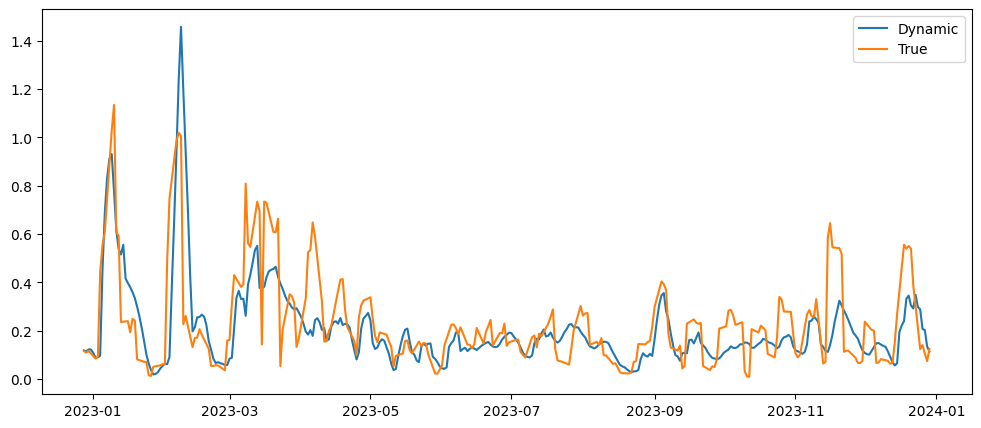

In [152]:

sigma2_true = df.loc[df_garch_test.index[ROLLING_WINDOW:].min():df_garch_test.index.max(),:].values

plt.figure(figsize=(12,5))
plt.plot(df_garch_test.index[ROLLING_WINDOW:],sigma2_preds, label="Dynamic")
plt.plot(df_garch_test.index[ROLLING_WINDOW:],sigma2_true, label="True")
#plt.plot(data_log_returns_sq.loc[df_garch_test.index.min():df_garch_test.index.max(),:], label="True vol")
plt.legend()
plt.show()

In [153]:
mean_absolute_percentage_error(sigma2_preds, sigma2_true)

0.5639548433527732

In [154]:
mean_squared_error(sigma2_preds, sigma2_true)

0.022226697949009302